In [1]:
from pathlib import Path
import sys
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "pyproject.toml").exists():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

In [2]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

from syssimx_examples.controlled_pendulum import MasterPendulum
import syssimx_examples.controlled_pendulum.components.fem.pendulum_config as config

In [3]:
from syssimx.components.fmu import FMUComponent

PLATFORM = sys.platform
demo_dir_path = _repo / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir

#fmu_paths

**Reference Solution from Modelica**

In [4]:
from OMPython import ModelicaSystem
reference = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.NoContact.Quantization")
reference.buildModel()
reference.simulate()
ref_sol_names = ('time', 'theta', 'theta_meas')
ref_sol = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}

In [4]:
set_point = FMUComponent(name="Set Point", fmu_path=fmu_paths['Trajectories']["SetPoint"], group="Controller")
pid = FMUComponent(name="PID", fmu_path=fmu_paths['Controllers']["PIDController"], group="Controller")
drive = FMUComponent(name="Drive", fmu_path=fmu_paths['Actuators']["DriveDynamic"], group="Actuator")

angle_sensor = FMUComponent(name="Angle Sensor", fmu_path=fmu_paths['Sensors']['AngleSensor'], group="Sensors")
angle_decoder = FMUComponent(name="Decoder", fmu_path=fmu_paths['Sensors']['AngleDecoder'], group="Controller")

In [5]:
init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 0  # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3    # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 7800  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.005
sim_params.t_end = 5
sim_params.with_contact = False
sim_params.use_gravity = True

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_parameters = {
    'mat_params': mat_params,
    'init_params': init_params,
    'sim_params': sim_params,
    'anim_params': anim_params,
}

pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FMU", switch_config=None)

pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)

t     = 0.0
dt    = pendulum.fem.sim_params.tau
t_end = pendulum.fem.sim_params.t_end

In [6]:
from syssimx.system.connection import Connection

c1 = Connection(
    src_comp=set_point.name,
    src_port=set_point.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c21 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_sensor.name,
    dst_port=angle_sensor.input_specs["theta"].name,
)

c22 = Connection(
    src_comp=angle_sensor.name,
    src_port=angle_sensor.output_specs["v_out"].name,
    dst_comp=angle_decoder.name,
    dst_port=angle_decoder.input_specs["v_in"].name,
)

c23 = Connection(
    src_comp=angle_decoder.name,
    src_port=angle_decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c3 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c4 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c5 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

connections = [c1, c21, c22, c23, c3, c4, c5]
components  = [set_point, pid, drive, pendulum, angle_decoder, angle_sensor]

In [7]:
from syssimx import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)

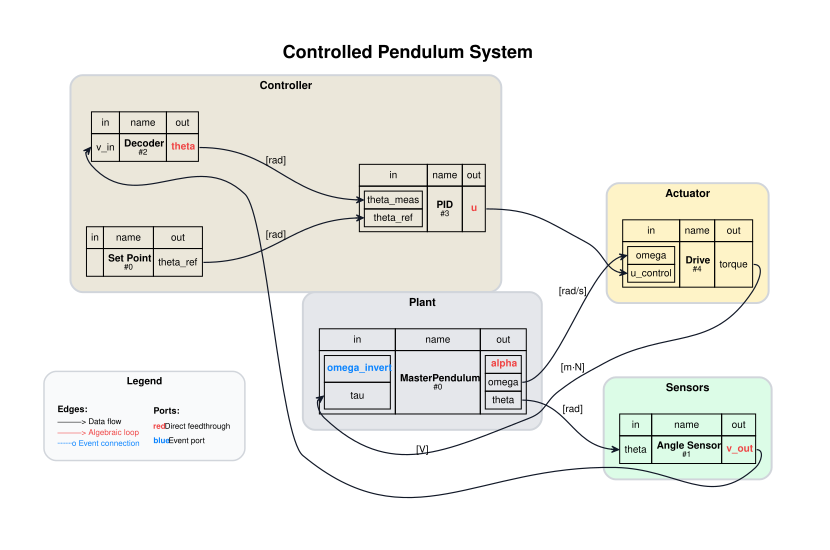

In [8]:
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

In [9]:
pendulum.setup_monitoring()
pendulum.display_monitoring()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [10]:
system.run(t, t_end, dt)

In [12]:
marker_size = 3
fem_style = {
    "color": "#063ccf",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
} 
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
}
eqb_style = {
    "color": "#24aa09",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
}

In [13]:
fem_hist = pendulum.fem.get_history()
fmu_hist = pendulum.fmu.get_history()
opensim_hist = pendulum.opensim.get_history()

t_fem = fem_hist['theta']['time']
theta_fem = fem_hist['theta']['values']
t_fmu = fmu_hist['theta']['time']
theta_fmu = fmu_hist['theta']['values']
t_opensim = opensim_hist['theta']['time']
theta_opensim = opensim_hist['theta']['values']

In [16]:
history.keys()

dict_keys(['Set Point', 'PID', 'Drive', 'MasterPendulum', 'Decoder', 'Angle Sensor', 'Events'])

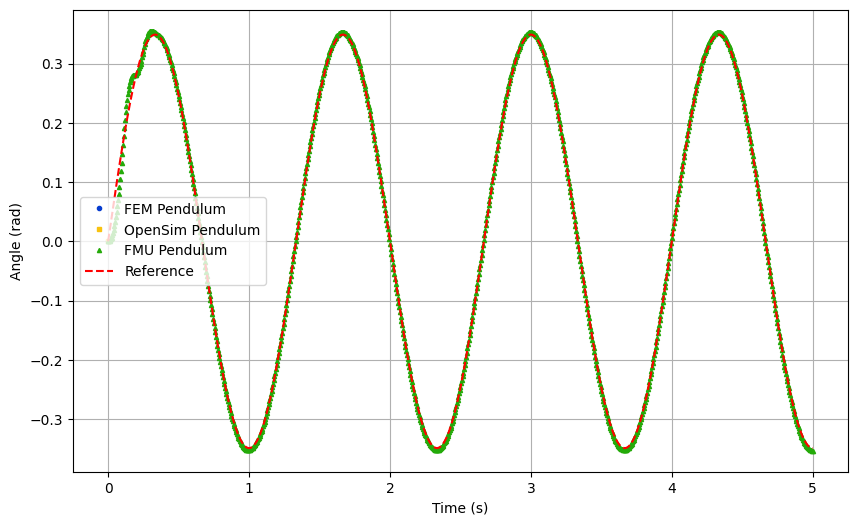

In [17]:
history = system.get_history()

ref_history = history["Set Point"]
t_ref, data = ref_history
q_ref = data["theta_ref"]

plt.figure(figsize=(10, 6))
plt.plot(t_fem, theta_fem, label="FEM Pendulum", **fem_style)
plt.plot(t_opensim, theta_opensim, label="OpenSim Pendulum", **opensim_style)
plt.plot(t_fmu, theta_fmu, label="FMU Pendulum", **eqb_style)
plt.plot(t_ref, q_ref, label="Reference", color="red", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.legend()
plt.grid()
plt.show()

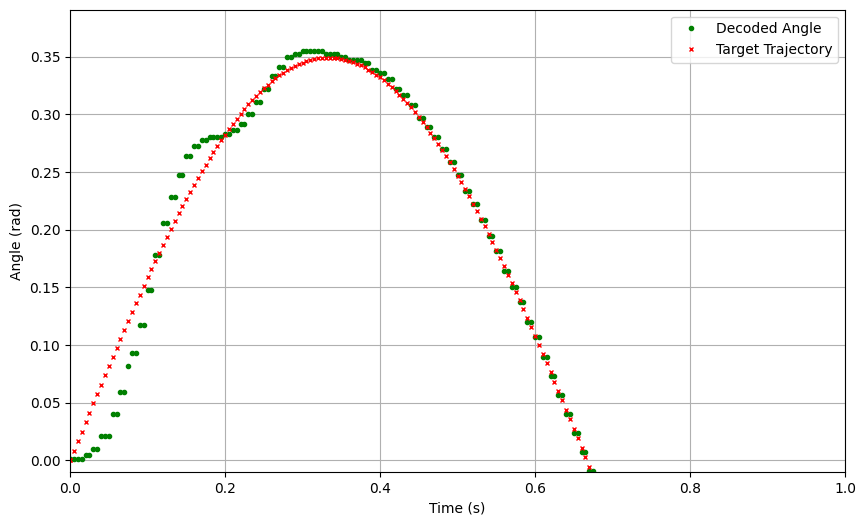

In [18]:
decoder_hist = angle_decoder.get_history()
t_decoder = decoder_hist["theta"]["time"]
theta_decoder = decoder_hist["theta"]["values"]

plt.figure(figsize=(10, 6))
plt.plot(t_decoder, theta_decoder, label="Decoded Angle", color="green", linestyle="None", marker="o", markersize=3)
plt.plot(t_ref, q_ref, label="Target Trajectory", color="red", linestyle="None", marker="x", markersize=3)
plt.xlim(0, 1)
plt.ylim(-0.01, np.max(theta_decoder)*1.1)
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.legend()
plt.grid()
plt.show()